# Learning embeddings

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# for importing and working with texts
import re
import requests
import string

# pytorch stuff
import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

# 1. Create a data loader to train a model

## Import text and create dictionary

In [2]:
# get raw text from internet
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c','â\x80\x9c','â\x80\x9d','\r\n','â\x80\x94','â\x80\x99','â\x80\x98','_', ]

# use regular expressions (re) to replace those strings with space
for str2match in strings2replace:
    text = re.compile(r'%s'%str2match).sub(' ', text)

# remove non-ASCII characters and numbers and make lower-case
text = re.sub(r'[^\x00-\x7F]+', ' ', text)
text = re.sub('\d+','',text).lower()

# split into words with >1 letters
words = re.split(f'[{string.punctuation}\s]+', text)
words = [item.strip() for item in words if item.strip()]
words = [item for item in words if len(item)>1]

# create the vocabualary
vocab = sorted(set(words))
n_words = len(words)
n_vocab = len(vocab)

# encoder/decoder look-up-tables (as python dictionaries)
word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for i, word in enumerate(vocab)}

# show a few keys in the dictionary
print(f'The book contains {n_words:,} words, {n_vocab:,} of which are unique and comprise the vocab.')
print(f'\n\nFirst 10 vocab words:\n',list(word2idx.keys())[:10])

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xb/2p09rqt55sj85gtsqtnpdnvh0000gp/T/ipykernel_45906/4043151826.py:12: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+','',text).lower()
/var/folders/xb/2p09rqt55sj85gtsqtnpdnvh0000gp/T/ipykernel_45906/4043151826.py:15: SyntaxWarning: invalid escape sequence '\s'
  words = re.split(f'[{string.punctuation}\s]+', text)


The book contains 30,698 words, 4,589 of which are unique and comprise the vocab.


First 10 vocab words:
 ['abandon', 'abandoned', 'able', 'abnormally', 'abominable', 'abominations', 'about', 'above', 'abruptly', 'absence']


In [3]:
# parameters for dataset
context_length = 8
stride = 2 # skipping

# initialize
inputs = []
targets = []

# overlapping sequences of context_length
for i in range(0, n_words-context_length, stride):
    # get a few words
    in_seq = words[i: i+context_length]
    target_seq = words[i+1: i+1+context_length]
    # append to the lists
    inputs.append([word2idx[w] for w in in_seq])
    targets.append([word2idx[w] for w in target_seq])

print(inputs[123])
print(targets[123])

[1342, 4304, 4119, 342, 4296, 3388, 1474, 131]
[4304, 4119, 342, 4296, 3388, 1474, 131, 209]


In [4]:
# a closer look:
print("Inputs: ", inputs[4])
print("Targets:", targets[4])
print("")
print("Inputs: ", inputs[5])
print("Targets:", targets[5])
# this is what we need although we need it in torch Dataset/DataLoader format

Inputs:  [2416, 131, 2172, 506, 4451, 783, 2167, 2005]
Targets: [131, 2172, 506, 4451, 783, 2167, 2005, 4042]

Inputs:  [2172, 506, 4451, 783, 2167, 2005, 4042, 2416]
Targets: [506, 4451, 783, 2167, 2005, 4042, 2416, 2006]


In [5]:
# we need each list to be a tensor
torch.tensor(inputs[4])

tensor([2416,  131, 2172,  506, 4451,  783, 2167, 2005])

## Create a class for a dataset object

In [6]:
# create a class for a dataset
class WordDataset(Dataset):
    def __init__(self, text, word2idx, context_length=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []
        self.word2idx = word2idx # stored locally in the object

        # overlapping sequences of context_length
        for i in range(0, len(text)-context_length, stride):
            # get a few words
            in_seq = text[i: i+context_length]
            targ_seq = text[i+1: i+1+context_length]

            # append to the lists
            self.inputs.append(torch.tensor([word2idx[w] for w in in_seq]))
            self.targets.append(torch.tensor([word2idx[w] for w in targ_seq]))
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

# create an instance!
context_length = 6
stride = 3 # skipping over tokens
text_dataset = WordDataset(words, word2idx, context_length, stride)

text_dataset[4]

(tensor([4451,  783, 2167, 2005, 4042, 2416]),
 tensor([ 783, 2167, 2005, 4042, 2416, 2006]))

## a dataloader for training

In [7]:
# also need a dataloader
dataloader = DataLoader(
    text_dataset,
    batch_size=2, # 2 for looking; 32 for training
    shuffle=True,
    drop_last=True
)

# lets have a look at the indices
X, y = next(iter(dataloader))
print("Inputs:")
print(X), print("")

print("Targets:")
print(y), print("\n\n\n")

# and the words
print("Inputs in words (first batch):")
print([idx2word[item.item()] for item in X[0]])
print("")

print("Targets in words (first batch):")
print([idx2word[item.item()] for item in y[0]])

Inputs:
tensor([[4188, 4119, 1608, 3131,    6, 2186],
        [ 919, 2731, 4429, 1349, 1606, 4050]])

Targets:
tensor([[4119, 1608, 3131,    6, 2186, 2041],
        [2731, 4429, 1349, 1606, 4050,  137]])




Inputs in words (first batch):
['tried', 'to', 'frame', 'question', 'about', 'it']

Targets in words (first batch):
['to', 'frame', 'question', 'about', 'it', 'in']


# 2. Build a model to learn the embeddings

In [8]:
np.logspace(np.log10(1000), np.log10(100000), 23)

array([  1000.        ,   1232.84673944,   1519.91108295,   1873.81742286,
         2310.12970008,   2848.03586844,   3511.19173422,   4328.76128108,
         5336.69923121,   6579.33224658,   8111.3083079 ,  10000.        ,
        12328.46739442,  15199.11082953,  18738.1742286 ,  23101.29700083,
        28480.35868436,  35111.91734215,  43287.61281083,  53366.99231206,
        65793.32246576,  81113.08307897, 100000.        ])

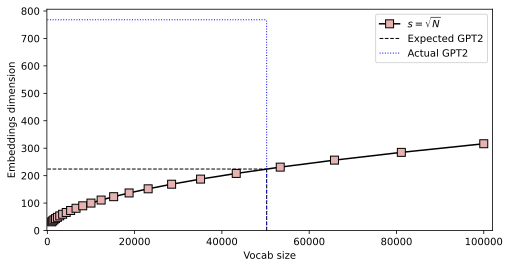

In [9]:
# exploring dimensionality based on vocab size

# vocab sizes
N = np.logspace(np.log10(1000), np.log10(100000), 23)

# heuristic for non-LLM models like Word2Vec or GloVe:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [50257, 768]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N, embdim, 'ks-', markersize=8, markerfacecolor=[.9,.7,.7], label=r'$s = \sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]], 
         [0,np.sqrt(gpt2dims[0])], 
         'k--', 
         linewidth=1, 
         label='Expected GPT2')
plt.plot([0,gpt2dims[0]], 
         [np.sqrt(gpt2dims[0]),
          np.sqrt(gpt2dims[0])],
          'k--',
          linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],
         [0,gpt2dims[1]],
         'b:',
         linewidth=1,
         label='Actual GPT2')
plt.plot([0,gpt2dims[0]],
         [gpt2dims[1],gpt2dims[1]],
         'b:',
         linewidth=1)

plt.gca().set(xlabel="Vocab size",
              ylabel="Embeddings dimension",
              xlim=[-100,N[-1]+2000],
              ylim=[0,None])

plt.legend()
plt.show()

## Create and explore an embedding layer

In [11]:
# dimensionality of embedding space (arbitrarily set to 100)
embedding_dimension = 100

# create a random embedding 
embedding_layer = nn.Embedding(n_vocab, embedding_dimension)

# let's see its size
embedding_layer.weight.shape

torch.Size([4589, 100])

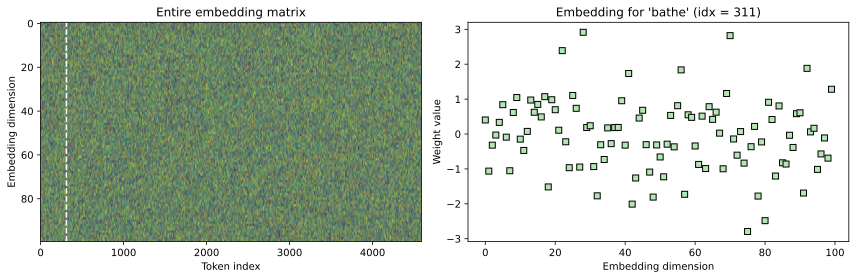

In [12]:
# what does it look like?

_, axs = plt.subplots(1,2,figsize=(12,4))
axs[0].imshow(embedding_layer.weight.detach().T, aspect='auto', vmin=-1, vmax=1)
axs[0].set(ylabel="Embedding dimension",
           xlabel="Token index",
           title="Entire embedding matrix")

# pick a word at random
random_word = np.random.choice(vocab)

# plot its embedding
axs[1].plot(embedding_layer.weight.detach()[word2idx[random_word],:], 'ks', markerfacecolor=[.7,.9,.7])
axs[0].axvline(word2idx[random_word], color='w', linestyle='--')
axs[1].set(xlabel="Embedding dimension",
           ylabel="Weight value",
           title=f"Embedding for '{random_word}' (idx = {word2idx[random_word]})")

plt.tight_layout()
plt.show()

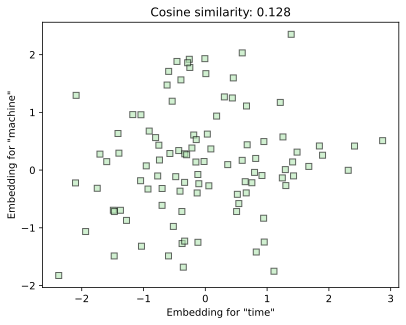

In [13]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1 = embedding_layer.weight.detach()[word2idx[word1],:]
embed2 = embedding_layer.weight.detach()[word2idx[word2],:]

# cosine similiarity between them
cosSim = torch.dot(embed1,embed2)/(torch.norm(embed1)*torch.norm(embed2))

# vizualize
plt.plot(embed1, embed2, 'ks', markerfacecolor=[.7,.9,.7], alpha=.6)
plt.gca().set(xlabel=f'Embedding for "{word1}"',
              ylabel=f'Embedding for "{word2}"',
              title=f'Cosine similarity: {cosSim:.3f}')
plt.show()

## Build the model

In [15]:
class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super(EmbeddingModel, self).__init__()

        # embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # linear layers
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)
    
    def forward(self, inputs):
        # extract and flatten embeddings
        # [batch_size, context_size * embedding_dim]
        embeds = self.embedding(inputs).view(inputs.shape[0], -1)
        # fully connected layers
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)
        # log softmax for classification
        # (note: NLLLoss expects logprobs as inputs)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs
    
# create a model instance
model = EmbeddingModel(vocab_size=n_vocab,
                       embedding_dim=embedding_dimension,
                       context_size=context_length)
print(model)

# apply Xavier weight distribution
for param in model.parameters():
    if param.dim()>1: # also excludes biases
        nn.init.xavier_normal_(param)

EmbeddingModel(
  (embedding): Embedding(4589, 100)
  (linear1): Linear(in_features=600, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=4589, bias=True)
)


In [16]:
# let's test the model
X, y = next(iter(dataloader))
model_out = model(X)

print('Input to model:')
print(X), print('')

print(f'Output from model (size: {list(model_out.detach().shape)}):')
print(model_out)

Input to model:
tensor([[ 319,   96, 4042, 3356, 4119, 3890],
        [3130, 4119, 4045, 3712, 2281, 2576]])

Output from model (size: [2, 4589]):
tensor([[-8.3965, -8.4617, -8.3441,  ..., -8.4017, -8.4560, -8.4704],
        [-8.3972, -8.4536, -8.3414,  ..., -8.4009, -8.4604, -8.4721]],
       grad_fn=<LogSoftmaxBackward0>)


In [17]:
# log soft-max output:
print(model_out.detach()[0])
print("")

# shouldn't the sum be 1?
print(f'Log softmax sum = {model_out.detach()[0].sum():.3f}')

# ah, it's *log* softmax :D
print(f'exp(log(softmax)) sum = {torch.exp(model_out.detach()[0]).sum():.3f}')

tensor([-8.3965, -8.4617, -8.3441,  ..., -8.4017, -8.4560, -8.4704])

Log softmax sum = -38697.926
exp(log(softmax)) sum = 1.000


In [18]:
# find the word with the highest probability
print('Model input:')
print([idx2word[w.item()] for w in X[0]])
print('')

print('Model output:')
print(idx2word[model_out[0].argmax().item()])

Model input:
['be', 'all', 'the', 'roots', 'to', 'stumble']

Model output:
tire


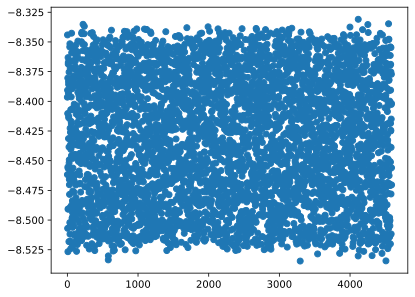

In [19]:
plt.plot(model_out[0].detach(), 'o');

## Have the model generate text

In [20]:
# grab some data from the loader
X,y = next(iter(dataloader))

print('First input:')
print(' '.join([idx2word[w.item()] for w in X[0]]))
print('\nSubsequent inputs:')

# text generation
for _ in range(context_length):
    # get output for this input
    Y = model(X)

    # pick the most likely next word
    next_word = Y[0].argmax().item()

    # create new input for the next iteration (word)
    X[0] = torch.concatenate((X[0][1:], torch.tensor([next_word])))

    # print out the generated text so far
    print(' '.join([idx2word[w.item()] for w in X[0]]))

First input:
watching some of the little people

Subsequent inputs:
some of the little people her
of the little people her tampering
the little people her tampering what
little people her tampering what lead
people her tampering what lead coral
her tampering what lead coral questionings


## How big is our model?

In [21]:
# summary of model and parameters
summary(model, input_data=X, col_names=['input_size','output_size','num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
EmbeddingModel                           [2, 6]                    [2, 4589]                 --
├─Embedding: 1-1                         [2, 6]                    [2, 6, 100]               458,900
├─Linear: 1-2                            [2, 600]                  [2, 128]                  76,928
├─Linear: 1-3                            [2, 128]                  [2, 4589]                 591,981
Total params: 1,127,809
Trainable params: 1,127,809
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.26
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 4.51
Estimated Total Size (MB): 4.60